# **Implementación del caso de 10 Qubits.**

In [107]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [108]:
N10 = 261980999226229

## **Implementación con 8 Qubits**

In [109]:
seed = 51

In [110]:
eightQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [111]:
B8, t8 = eightQubit.generate_cvp(10)
print(f'B8 = \n{B8}')
print(f't8 = \n{t8}')

B8 = 
[ 2 0 0 0 0 0 0 0  6931 ]
[ 0 3 0 0 0 0 0 0 10986 ]
[ 0 0 2 0 0 0 0 0 16094 ]
[ 0 0 0 4 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 28332 ]
[ 0 0 0 0 0 0 0 4 29444 ]
t8 = 
(0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [112]:
D8, b8_op, res8_vector, sign_step8, w8, dist8 = eightQubit.babai_algorithm(B8, t8, delta = 0.75)
print(f'D8 = \n{D8}\n')
print(f'b8_op = \n{b8_op}\n')
print(f'res8_vector = \n{res8_vector}\n')
print(f'sign_step8 = \n{sign_step8}\n')
print(f'w8 = \n{w8}\n')
print(f'dist8 = \n{dist8}\n')

D8 = 
[  2  0 -4 -4  3  0 -2  4  1 ]
[  0 -3  4  0 -2  3 -1  4  5 ]
[  6 -3  0  0 -4  0  2  4 -1 ]
[  4  0 -2  0 -2  6  1 -4 -4 ]
[ -4  0  6  4 -1  3 -3  4 -3 ]
[  2 -6  6  0  2 -3 -3  4 -2 ]
[  2 -6 -4  4  1 -3  0  4  4 ]
[ -8 -3  0  0 -3  3  3  0 -2 ]

b8_op = 
[     2      0      2      0      0      3     10      0 331994]

res8_vector = 
[ -2   0  -2   0   0  -3 -10   0  -1]

sign_step8 = 
[ 1 -1 -1 -1  1  1  1 -1]

w8 = 
(-8765, 35541, -13511, -8003, -15327, -12503, 6562, -10148)

dist8 = 
10.862780491200215



In [113]:
qubo8 = eightQubit.define_qubo(D8, res8_vector, sign_step8)
print(qubo8.prettyprint())

Hc8, offset8 = eightQubit.define_hamiltonian(qubo8)
print(f'Offset = {offset8}')
print(f'Hamiltonian = {Hc8}')


Problem name: quboProblem

Minimize
  66*z_0^2 - 2*z_0*z_1 - 22*z_0*z_2 + 24*z_0*z_3 - 64*z_0*z_4 + 12*z_0*z_5
  + 54*z_0*z_6 + 66*z_0*z_7 + 80*z_1^2 + 52*z_1*z_2 - 46*z_1*z_3 - 78*z_1*z_4
  - 76*z_1*z_5 - 54*z_1*z_6 + 22*z_1*z_7 + 82*z_2^2 + 44*z_2*z_3 + 14*z_2*z_4
  - 68*z_2*z_5 - 76*z_2*z_6 - 38*z_2*z_7 + 93*z_3^2 + 30*z_3*z_4 + 74*z_3*z_5
  + 72*z_3*z_6 + 6*z_3*z_7 + 112*z_4^2 + 96*z_4*z_5 - 44*z_4*z_6 - 82*z_4*z_7
  + 118*z_5^2 + 70*z_5*z_6 + 36*z_5*z_7 + 114*z_6^2 + 36*z_6*z_7 + 104*z_7^2
  - 46*z_0 - 24*z_1 - 62*z_2 - 56*z_3 - 40*z_4 - 50*z_5 - 18*z_6 - 42*z_7 + 118

Subject to
  No constraints

  Binary variables (8)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7

Offset = 348.0
Hamiltonian = SparsePauliOp(['IIIIIIIZ', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZI', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII'

In [114]:
circuit8 = eightQubit.construct_circuit(Hc8, reps = 1)
print(circuit8.decompose())

     ┌───┐»
q_0: ┤ H ├»
     ├───┤»
q_1: ┤ H ├»
     ├───┤»
q_2: ┤ H ├»
     ├───┤»
q_3: ┤ H ├»
     ├───┤»
q_4: ┤ H ├»
     ├───┤»
q_5: ┤ H ├»
     ├───┤»
q_6: ┤ H ├»
     ├───┤»
q_7: ┤ H ├»
     └───┘»
«     ┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                                                                                                                                                                                                                                                                                                             

In [115]:
x0 = np.asarray([0.0]*circuit8.num_parameters)
optParameters8 = eightQubit.qaoa_algorithm(circuit8, Hc8, x0)

In [116]:
for param in optParameters8.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = -0.4799726604811829
γ[0] = 0.008447652215877989


In [117]:
results8 = eightQubit.sample_from_parameters(circuit8, optParameters8, shots = 10_000)
print(len(results8))
for bitstring, count in results8.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

216
Bistring: 00000100 -> Counts: 391
Bistring: 00010011 -> Counts: 374
Bistring: 00100110 -> Counts: 339
Bistring: 00000000 -> Counts: 310
Bistring: 00010010 -> Counts: 259
Bistring: 00000101 -> Counts: 253
Bistring: 00010111 -> Counts: 243
Bistring: 01010110 -> Counts: 240
Bistring: 00000010 -> Counts: 233
Bistring: 00001010 -> Counts: 229
Bistring: 00100100 -> Counts: 226
Bistring: 10010110 -> Counts: 211
Bistring: 10010010 -> Counts: 205
Bistring: 10010100 -> Counts: 201
Bistring: 01010111 -> Counts: 192
Bistring: 00100010 -> Counts: 185
Bistring: 10000100 -> Counts: 184
Bistring: 00010101 -> Counts: 171
Bistring: 00100111 -> Counts: 165
Bistring: 11010110 -> Counts: 164
Bistring: 00010110 -> Counts: 163
Bistring: 01010010 -> Counts: 160
Bistring: 01000100 -> Counts: 158
Bistring: 00000110 -> Counts: 158
Bistring: 00010001 -> Counts: 131
Bistring: 01000110 -> Counts: 131
Bistring: 00000001 -> Counts: 128
Bistring: 00100101 -> Counts: 128
Bistring: 10010101 -> Counts: 122
Bistring: 

In [118]:
nD8 = eightQubit.integer_to_matrix(D8)
vnew8 = eightQubit.bitstring2latticeVectors(nD8, results8.keys(), sign_step8, b8_op)
for vect8 in vnew8:
    print(vect8)

[    -4      3      2      0      4      3      8     -4 331995]
[     0      3      0      0      4      3      6      4 331987]
[    -2      0      4      0      8     -3      6     -4 331988]
[     2      0      2      0      0      3     10      0 331994]
[    -2      3      4      4      1      3      8      0 331986]
[    -2      3     -2     -4      7      3      6      0 331996]
[    -6      6      0      0      8      3      4      0 331988]
[    -6      0      0      8      6      0      6      0 331991]
[     2      3     -2      0      2      0     11     -4 331989]
[    -2      3      0      0      4     -6     10      0 331993]
[    -2     -3      8      0      6      0      5      0 331993]
[     0      9      4      4      8      0      3     -4 331989]
[     6      6      4      4      4      0      5      0 331988]
[     0      6      8      4      6      3      2      0 331994]
[    -4      0     -4      4      9      0      4      4 331992]
[     4     -3      4    

In [119]:
distances8 = eightQubit.get_distances(vnew8, t8)
for dist8 in distances8:
    print(dist8)

11.74734012447073
11.045361017187261
13.038404810405298
10.862780491200215
12.96148139681572
11.661903789690601
13.638181696985855
13.2664991614216
13.19090595827292
12.84523257866513
11.74734012447073
14.7648230602334
13.038404810405298
12.884098726725126
12.727922061357855
12.884098726725126
12.727922061357855
12.569805089976535
13.341664064126334
13.2664991614216
15.937377450509228
12.884098726725126
12.569805089976535
15.684387141358123
12.083045973594572
14.560219778561036
11.74734012447073
12.165525060596439
12.884098726725126
13.74772708486752
14.352700094407323
12.449899597988733
13.038404810405298
14.035668847618199
15.556349186104045
12.922847983320086
14.966629547095765
13.856406460551018
13.416407864998739
13.784048752090222
15.874507866387544
13.341664064126334
14.696938456699069
14.7648230602334
14.0
14.071247279470288
13.784048752090222
16.55294535724685
14.142135623730951
13.711309200802088
16.55294535724685
16.76305461424021
13.19090595827292
14.696938456699069
14.7986

In [120]:
nB8 = eightQubit.integer_to_matrix(B8)
uv_pairs8 = eightQubit.vectors2uv_pairs(nB8, vnew8)
print(uv_pairs8)

[[19915752615267795 76]
 [261868027467189 1]
 [129352557022507225 494]
 [262079207058370 1]
 [523704989883075 2]
 [18344544450464661 70]
 [2094705767700117 8]
 [2095297617885241 8]
 [24881396719341558 95]
 [88548500089421427 338]
 [1572102054235625 6]
 [4976110986617925 19]
 [261930391846200 1]
 [262070340406875 1]
 [26192773830301463 100]
 [10213206469368100 39]
 [4980419307818460 19]
 [2096063541654225 8]
 [23829516041101331 91]
 [3405871519729602 13]
 [79594097822264025 304]
 [785826051486091 3]
 [7864168981413437 30]
 [1890770913674116353 7220]
 [262037768531825 1]
 [16176595594767439909 61750]
 [9173316356123348 35]
 [5502683577794425 21]
 [262085885854650 1]
 [27239768591429625 104]
 [398405875629322253 1521]
 [6815838201665075 26]
 [262100173335000 1]
 [44277791974589250 169]
 [8708014138755186387 33250]
 [13620692197897455 52]
 [4191878430114375 16]
 [229184353172620164 875]
 [262157171406240 1]
 [261945928992528 1]
 [841041742627105800 3211]
 [262159937104450 1]
 [261916113620

In [121]:
sr_pairs8 = eightQubit.uv_pairs2sr_pairs(uv_pairs8)
print(sr_pairs8)

[]


In [122]:
probs8 = eightQubit.get_probs(results8.values(), shots = 10_000)

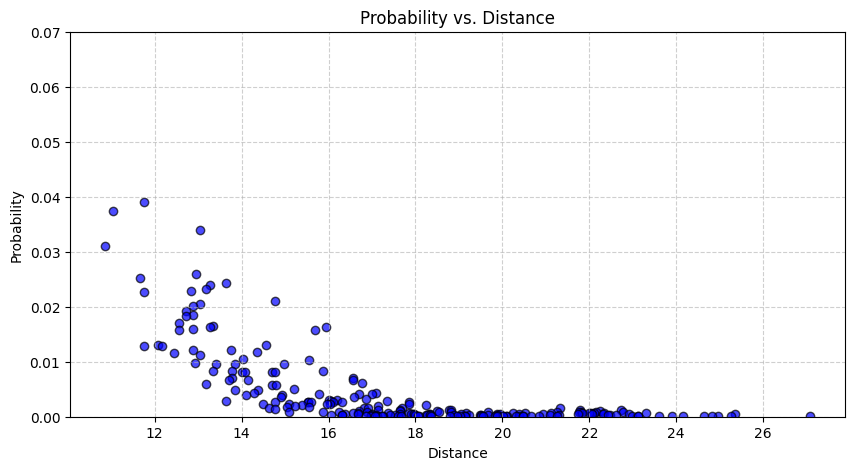

In [123]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances8, probs8, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.07) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Implementación con 10 Qubits**

In [124]:
seed = 42

In [125]:
tenQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [126]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [127]:
B10, t10 = tenQubit.generate_cvp(10)
print(f'B10 = \n{B10}')
print(f't10 = \n{t10}')

B10 = 
[ 5 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 1 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 4 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 2 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 5 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 3 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 4 33673 ]
t10 = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [128]:
D10, b10_op, res10_vector, sign_step10, w10, dist10 = tenQubit.babai_algorithm(B10, t10, delta = 0.75)
print(f'D10 = \n{D10}\n')
print(f'b10_op = \n{b10_op}\n')
print(f'res10_vector = \n{res10_vector}\n')
print(f'sign_step10 = \n{sign_step10}\n')
print(f'w10 = \n{w10}\n')
print(f'dist10 = \n{dist10}\n')

D10 = 
[  0  1  3 -1  0  2  0  3 -4  0  4 ]
[  5  3 -3  2  0  0  0  0 -4  0  3 ]
[  0  4 -3  1 -4 -2  0  0 -2  4 -1 ]
[  0  4 -3 -1  0  4 -5  0 -2  0  2 ]
[  0  1 -3 -3  0 -2  5  3  2  0 -3 ]
[  0 -1 -6  0  0 -4  0  3  2  4  0 ]
[ -5 -2  3  4  0  0  0  0 -2 -4 -1 ]
[  0  5  0  3  0 -4 -5  0  0 -4  4 ]
[ -5  4  0 -2  0  0  0 -3  2  0  6 ]
[ -5  2  0  1  4  0  0 -3 -4  4 -2 ]

b10_op = 
[     0      1      0      6      0      4      0      6      6      0
 331991]

res10_vector = 
[ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

sign_step10 = 
[ 1  1  1 -1 -1 -1 -1  1  1  1]

w10 = 
(15714, 20489, -11636, -10577, -17862, 19313, 3326, -7285, 28799, -11636)

dist10 = 
11.357816691600547



In [129]:
qubo10 = tenQubit.define_qubo(D10, res10_vector, sign_step10)
print(qubo10.prettyprint())
Hc10, offset10 = tenQubit.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  56*z_0^2 + 40*z_0*z_1 - 12*z_0*z_2 - 40*z_0*z_3 + 40*z_0*z_4 + 52*z_0*z_5
  - 14*z_0*z_6 + 20*z_0*z_7 + 26*z_0*z_8 + 72*z_1^2 + 56*z_1*z_2 - 66*z_1*z_3
  + 22*z_1*z_4 - 14*z_1*z_5 + 54*z_1*z_6 + 66*z_1*z_7 - 14*z_1*z_8 - 14*z_1*z_9
  + 67*z_2^2 - 36*z_2*z_3 - 26*z_2*z_4 - 68*z_2*z_5 + 48*z_2*z_6 + 22*z_2*z_7
  + 8*z_2*z_8 + 38*z_2*z_9 + 75*z_3^2 - 54*z_3*z_4 - 12*z_3*z_5 - 38*z_3*z_6
  - 68*z_3*z_7 - 52*z_3*z_8 - 22*z_3*z_9 + 70*z_4^2 + 76*z_4*z_5 - 48*z_4*z_6
  + 66*z_4*z_7 + 26*z_4*z_8 + 24*z_4*z_9 + 82*z_5^2 - 72*z_5*z_6 + 10*z_5*z_7
  + 18*z_5*z_8 + 6*z_5*z_9 + 75*z_6^2 - 28*z_6*z_7 + 2*z_6*z_8 - 38*z_6*z_9
  + 107*z_7^2 + 76*z_7*z_8 - 22*z_7*z_9 + 94*z_8^2 + 40*z_8*z_9 + 91*z_9^2
  - 22*z_0 - 30*z_1 - 16*z_2 + 4*z_3 - 22*z_4 - 26*z_5 - 24*z_6 - 2*z_7 - 52*z_8
  - 60*z_9 + 129

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 418.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI'

In [130]:
circuit10 = tenQubit.construct_circuit(Hc10, reps= 1)
print(circuit10.decompose(reps = 2))

     ┌────────────┐ ┌────────────────┐                              »
q_0: ┤ U(π/2,0,π) ├─┤ Rz((-90)*γ[0]) ├─■─────────────■──────────────»
     ├────────────┤┌┴────────────────┤ │ZZ(20*γ[0])  │              »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-107)*γ[0]) ├─■─────────────┼──────────────»
     ├────────────┤└┬────────────────┤               │ZZ((-6)*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz((-66)*γ[0]) ├───────────────■──────────────»
     ├────────────┤ └┬──────────────┬┘                              »
q_3: ┤ U(π/2,0,π) ├──┤ Rz(115*γ[0]) ├───────────────────────────────»
     ├────────────┤┌─┴──────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-111)*γ[0]) ├──────────────────────────────»
     ├────────────┤└┬────────────────┤                              »
q_5: ┤ U(π/2,0,π) ├─┤ Rz((-54)*γ[0]) ├──────────────────────────────»
     ├────────────┤ └┬─────────────┬─┘                              »
q_6: ┤ U(π/2,0,π) ├──┤ Rz(16*γ[0]) ├────────────────────────────────»
     ├────────────┤┌

In [131]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
optParameters10 = tenQubit.qaoa_algorithm(circuit10, Hc10, x0)

In [132]:
for param in optParameters10.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = 0.5090447457358702
γ[0] = -0.008621815614845957


In [133]:
results10 = tenQubit.sample_from_parameters(circuit10, optParameters10, shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

585
Bistring: 1001001000 -> Counts: 225
Bistring: 0000000000 -> Counts: 220
Bistring: 0000001000 -> Counts: 219
Bistring: 1001101000 -> Counts: 196
Bistring: 0001001000 -> Counts: 194
Bistring: 0001101100 -> Counts: 184
Bistring: 0001011000 -> Counts: 182
Bistring: 0001101000 -> Counts: 173
Bistring: 1001011000 -> Counts: 156
Bistring: 1001001001 -> Counts: 142
Bistring: 0100001000 -> Counts: 138
Bistring: 1011001000 -> Counts: 137
Bistring: 1000001010 -> Counts: 137
Bistring: 0000001010 -> Counts: 133
Bistring: 0001001001 -> Counts: 132
Bistring: 0000101100 -> Counts: 126
Bistring: 1000001000 -> Counts: 124
Bistring: 0000001100 -> Counts: 120
Bistring: 1000000000 -> Counts: 111
Bistring: 1001101010 -> Counts: 103
Bistring: 0000001101 -> Counts: 99
Bistring: 0001000000 -> Counts: 99
Bistring: 1001000000 -> Counts: 98
Bistring: 0000001001 -> Counts: 95
Bistring: 0000011000 -> Counts: 95
Bistring: 1001001010 -> Counts: 91
Bistring: 0011001000 -> Counts: 90
Bistring: 1011101000 -> Counts:

In [134]:
nD10 = tenQubit.integer_to_matrix(D10)
vnew10 = tenQubit.bitstring2latticeVectors(nD10, results10.keys(), sign_step10, b10_op)
for vect10 in vnew10:
    print(vect10)

[     0      1      0      4      4      0      5      3      6      8
 331988]
[     0      1      0      6      0      4      0      6      6      0
 331991]
[     0     -3      3      7      0      0      5      6      8      0
 331989]
[     0      2      6      4      4      4      5      0      4      4
 331988]
[     5     -1      0      3      0      0      5      6     10      4
 331990]
[     5      4      3      4     -4      2      5      3      6      4
 331989]
[     5     -2      3      6      0      2      0      3      8      4
 331993]
[     5      0      6      3      0      4      5      3      8      0
 331990]
[     0      0      3      7      4      2      0      0      4      8
 331991]
[     0      2      3      3      4      2      5      6      2      8
 331992]
[    -5      1      3      5      0      0      5      3     10      0
 331995]
[     0      6      0      7      4     -4      0      3      6      4
 331992]
[     0      2      0     10      4     

In [135]:
distances10 = tenQubit.get_distances(vnew10, t10)
for dist10 in distances10:
    print(dist10)

13.856406460551018
11.357816691600547
14.422205101855956
13.038404810405298
14.866068747318506
13.711309200802088
12.922847983320086
13.892443989449804
12.727922061357855
13.114877048604
14.071247279470288
13.379088160259652
13.379088160259652
13.564659966250536
14.177446878757825
14.106735979665885
14.730919862656235
14.933184523068078
12.649110640673518
13.114877048604
14.317821063276353
13.416407864998739
13.152946437965905
14.212670403551895
14.212670403551895
14.422205101855956
15.165750888103101
12.922847983320086
12.806248474865697
14.247806848775006
14.594519519326424
12.649110640673518
14.2828568570857
14.52583904633395
13.820274961085254
13.564659966250536
13.674794331177344
14.352700094407323
12.767145334803704
14.247806848775006
15.874507866387544
16.852299546352718
12.96148139681572
12.767145334803704
14.560219778561036
14.730919862656235
13.601470508735444
13.601470508735444
13.379088160259652
14.45683229480096
13.416407864998739
14.966629547095765
15.874507866387544
15.6

In [136]:
nB10 = tenQubit.integer_to_matrix(B10)
uv_pairs10 = tenQubit.vectors2uv_pairs(nB10, vnew10)
for pair10 in uv_pairs10:
    print(pair10)

[261871433827773 1]
[261991323844341 1]
[7071698751104155 27]
[261912761285175 1]
[785809757098954 3]
[2881406685691170 11]
[2358275479138670 9]
[261977923439050 1]
[261965433534805 1]
[262012871275155 1]
[524110863400845 2]
[44273270057020389 169]
[261948620080917 1]
[262013791156222 1]
[262078058335730 1]
[2881166688465975 11]
[1571097732684865 6]
[37449256864542873 143]
[523852316714727 2]
[262011783123090 1]
[2882267946636435 11]
[1310065736807646 5]
[1309739882231781 5]
[2358506064707975 9]
[21222711489550025 81]
[1309852200204702 5]
[44284284952292574 169]
[262013355501975 1]
[262054497183570 1]
[261880908106545 1]
[262077260557707 1]
[262154507478003 1]
[2881986154104582 11]
[523982095561925 2]
[2881746108614485 11]
[2882440977138450 11]
[786516396634150 3]
[2882954165114205 11]
[261989315983395 1]
[262118620497825 1]
[68370542845343375 261]
[187261881680842038 715]
[2882008827066915 11]
[262132826044635 1]
[7600277737807650 29]
[2882255976438930 11]
[7598947436446275 29]
[26217

In [137]:
sr_pairs10 = tenQubit.uv_pairs2sr_pairs(uv_pairs10)
print(sr_pairs10)

[]


In [138]:
probs10 = tenQubit.get_probs(results10.values(), shots = 10_000)

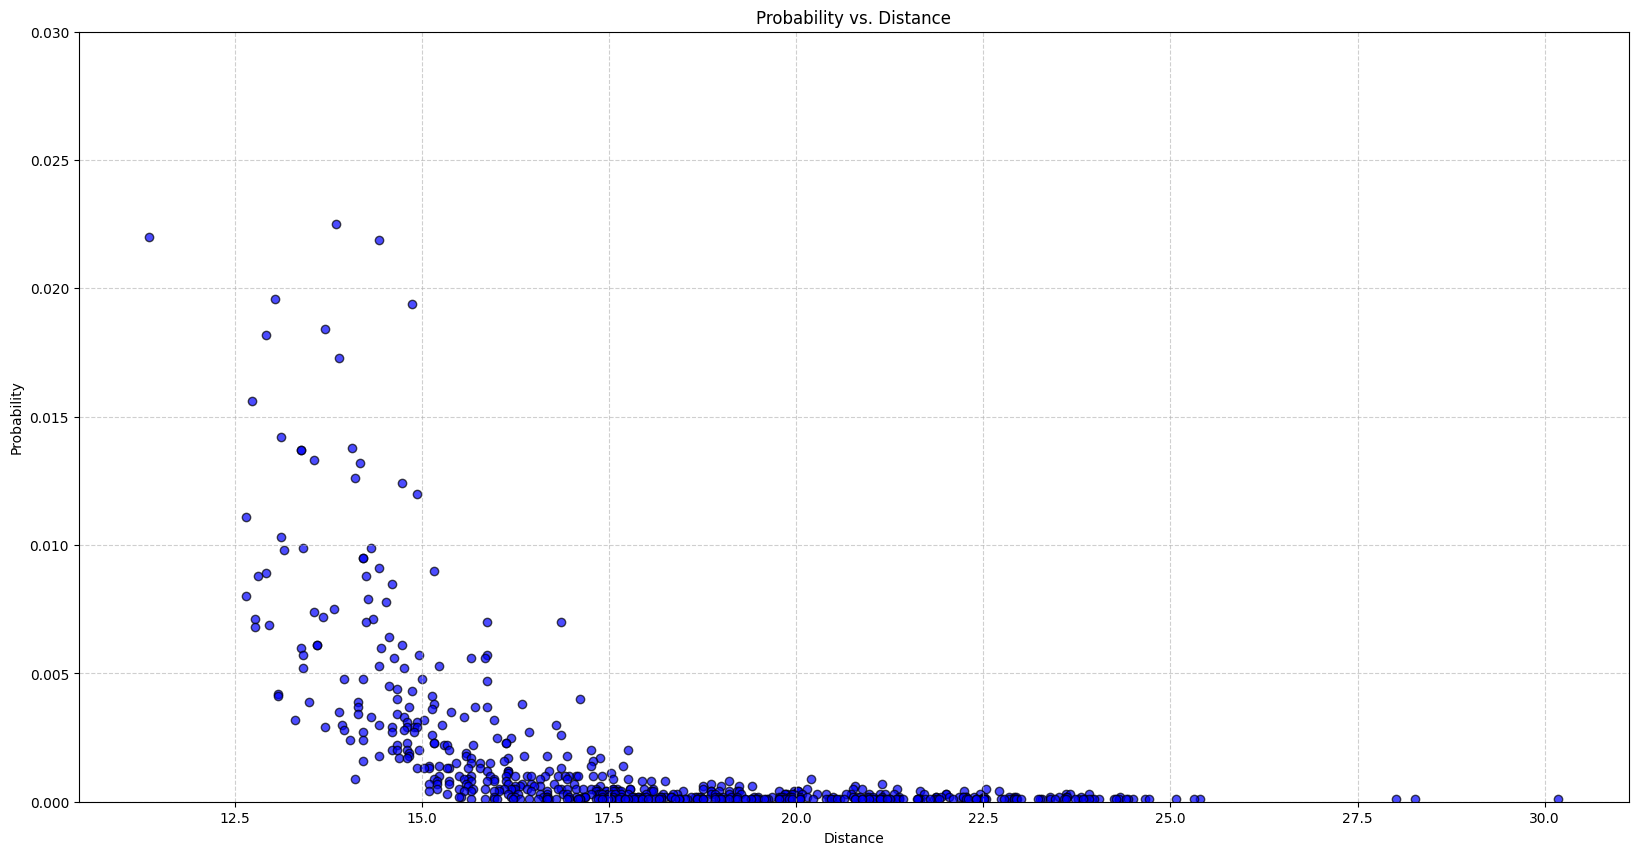

In [139]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.03) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()